In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
data = pd.read_csv("social_anxiety_dataset.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1968 non-null   float64
 1   Gender                             1911 non-null   object 
 2   Occupation                         2030 non-null   object 
 3   Sleep Hours                        1994 non-null   float64
 4   Physical Activity (hrs/week)       2030 non-null   float64
 5   Caffeine Intake (mg/day)           1936 non-null   float64
 6   Alcohol Consumption (drinks/week)  2030 non-null   int64  
 7   Smoking                            1924 non-null   object 
 8   Family History of Anxiety          2030 non-null   object 
 9   Stress Level (1-10)                2030 non-null   int64  
 10  Heart Rate (bpm)                   2030 non-null   int64  
 11  Breathing Rate (breaths/min)       2030 non-null   int64

In [4]:
num_data = ["Age",
"Sleep Hours",
"Physical Activity (hrs/week)",
"Caffeine Intake (mg/day)",
"Alcohol Consumption (drinks/week)",
"Stress Level (1-10)", "Heart Rate (bpm)",
"Breathing Rate (breaths/min)",
"Sweating Level (1-5)",
"Therapy Sessions (per month)",
"Diet Quality (1-10)",
"Anxiety Level (1-10)"]
cat_data = ["Gender", "Occupation", "Smoking", "Family History of Anxiety", "Dizziness", "Medication",
            "Recent Major Life Event", "Therapy History", "Target", "is_Anxious"
            ]

In [25]:
def box_plot_out(df:pd.DataFrame, col:str):

    # در این تابع باکس پلات ستون های عددی نمایش داده می شود و تعداد موارد خارج از محدوده مشخص می شود
    # برای وروردی col یک ستون عددی باید وارد شود


    fig, ax = plt.subplots(figsize=(15,4))


    # box plot
    q1, q3 = np.percentile(df[col].dropna(), [25, 75])
    iqr = q3 - q1

    l_bound = q1 - 1.5 * iqr
    u_bound = q3 + 1.5 * iqr

    num_lower = (df[col] < l_bound).sum()
    num_upper = (df[col] > u_bound).sum()


    sns.boxplot(x=df[col], boxprops={"facecolor":"lightgray"})
    ax.set_title("Boxplot")
    ax.text(s=f"number of upper outlier: {num_upper}", x=0.85, y=0.9, transform=ax.transAxes, bbox=dict(facecolor='red', alpha=0.5))
    ax.text(s=f"number of lower outlier: {num_lower}", x=0.1, y=0.9, transform=ax.transAxes, bbox=dict(facecolor='red', alpha=0.5))
    ax.set_facecolor("#FFFFFF")
    fig.patch.set_facecolor('#E6E6FA')
    plt.show()


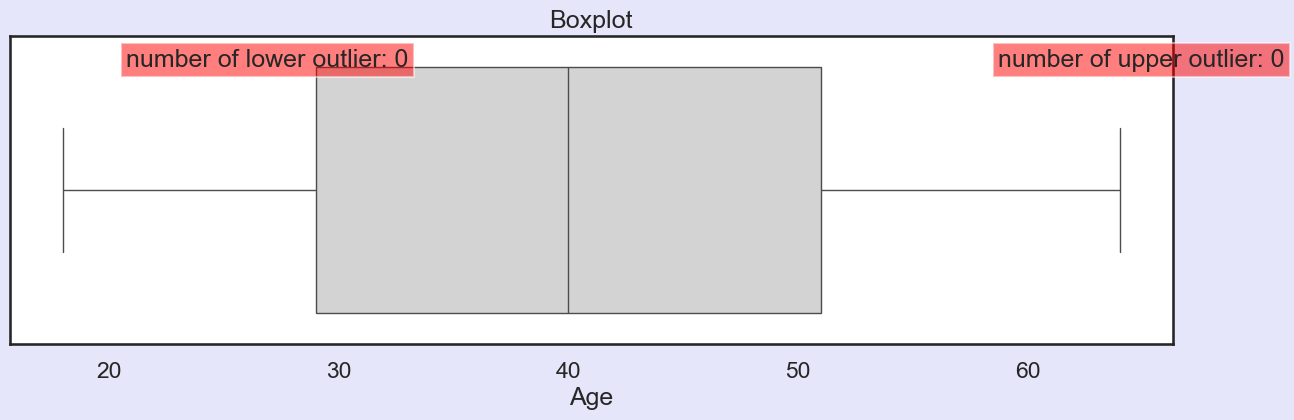

In [28]:
box_plot_out(data, "Age")

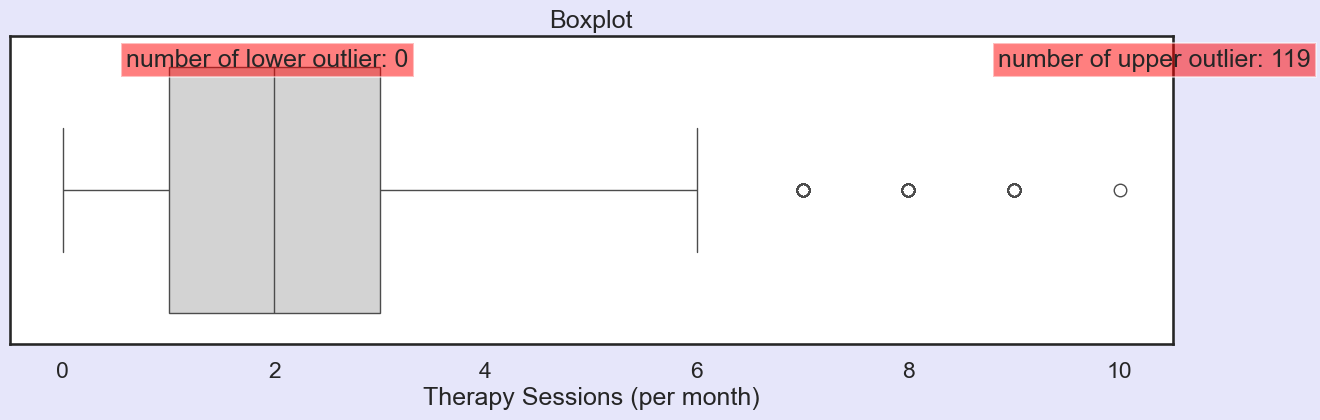

In [29]:
box_plot_out(data, "Therapy Sessions (per month)")

In [99]:
def scatter_anxiety(df:pd.DataFrame, x:str, y:str):
    sns.scatterplot(data=df, x=x, y=y, hue="is_Anxious")

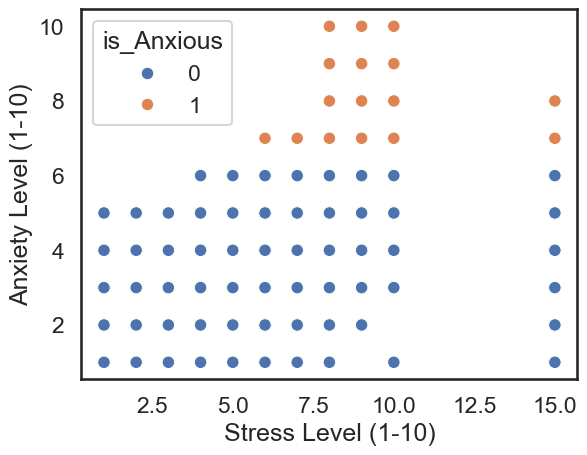

In [101]:
scatter_anxiety(data, "Stress Level (1-10)", "Anxiety Level (1-10)")

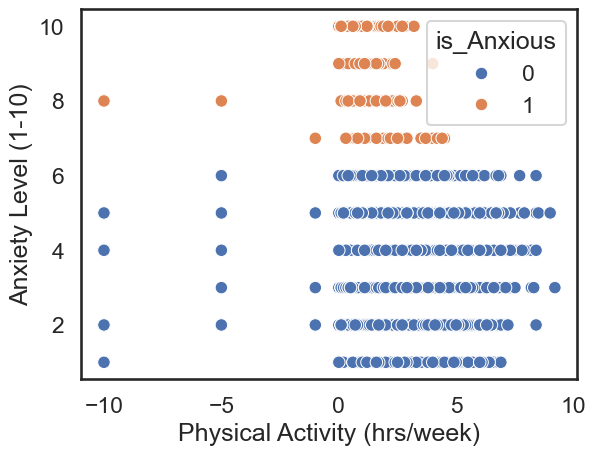

In [102]:
scatter_anxiety(data, "Physical Activity (hrs/week)", "Anxiety Level (1-10)")

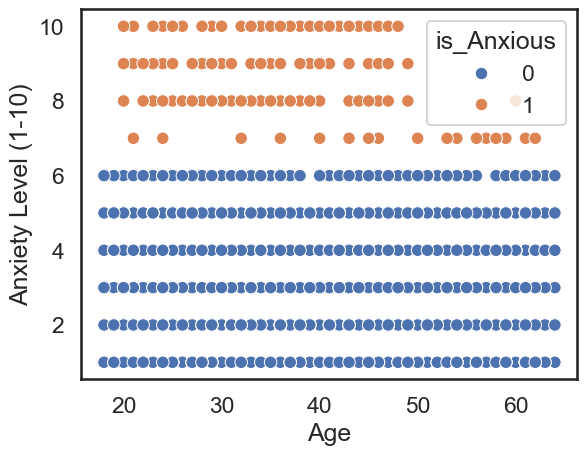

In [103]:
scatter_anxiety(data, x="Age", y="Anxiety Level (1-10)")

In [34]:
def bar_plot_cat(df, col):
    fig, ax = plt.subplots(1, 3, figsize=(20,5))
    sns.set_theme(context="talk", style="white")
    sns.countplot(df, x=col, hue="is_Anxious", palette="Set1", ax=ax[1])
    sns.barplot(df, x=col, y="is_Anxious", estimator=sum, errorbar=None, ax=ax[0])
    conti_tabel = pd.crosstab(df[col], df["is_Anxious"], normalize="index")
    conti_tabel.plot(kind="bar", stacked=True, ax=ax[2])
    ax[0].tick_params(axis="x", labelrotation=90)
    ax[1].tick_params(axis="x", labelrotation=90)
    ax[2].tick_params(axis="x", labelrotation=90)

    plt.show()



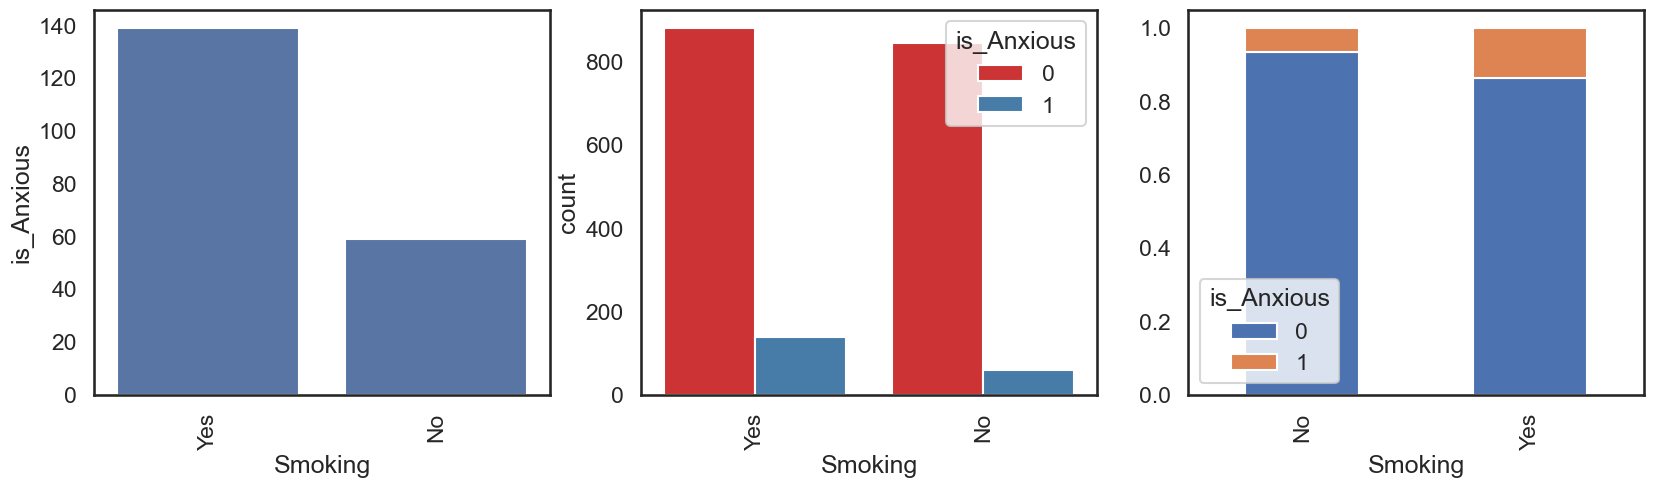

In [104]:
bar_plot_cat(data, "Smoking")

In [51]:
def heat_cat_plot(col:str):
    fig, ax = plt.subplots(1, 3, figsize=(20,5))

    percent_cont_table = pd.crosstab(data[col], columns="percent", normalize=True)*100
    sns.heatmap(percent_cont_table, annot=True, ax=ax[0], cbar=False)

    conti_tabel = pd.crosstab(data[col].dropna(), data["is_Anxious"])
    sns.heatmap(conti_tabel, annot=True, cmap="Blues", ax=ax[1], cbar=False)

    por_conti_tabel = pd.crosstab(data[col], data["is_Anxious"], normalize="index")
    sns.heatmap(por_conti_tabel, annot=True, fmt=".2f", cmap="Blues", ax=ax[2], cbar=False)


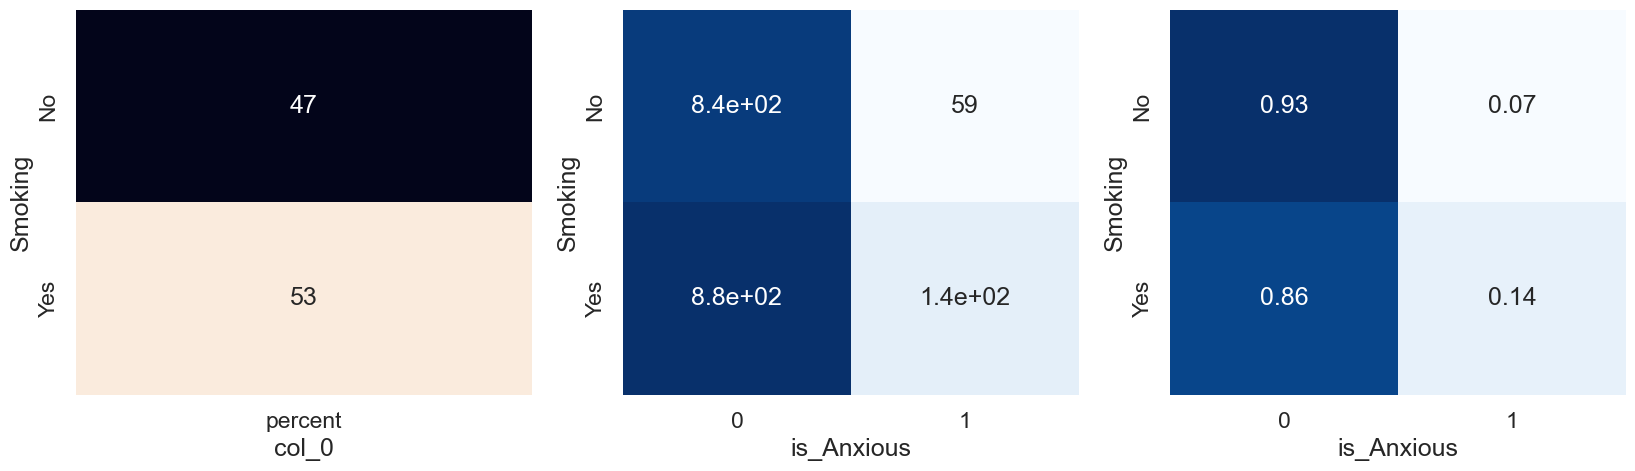

In [52]:
heat_cat_plot("Smoking")

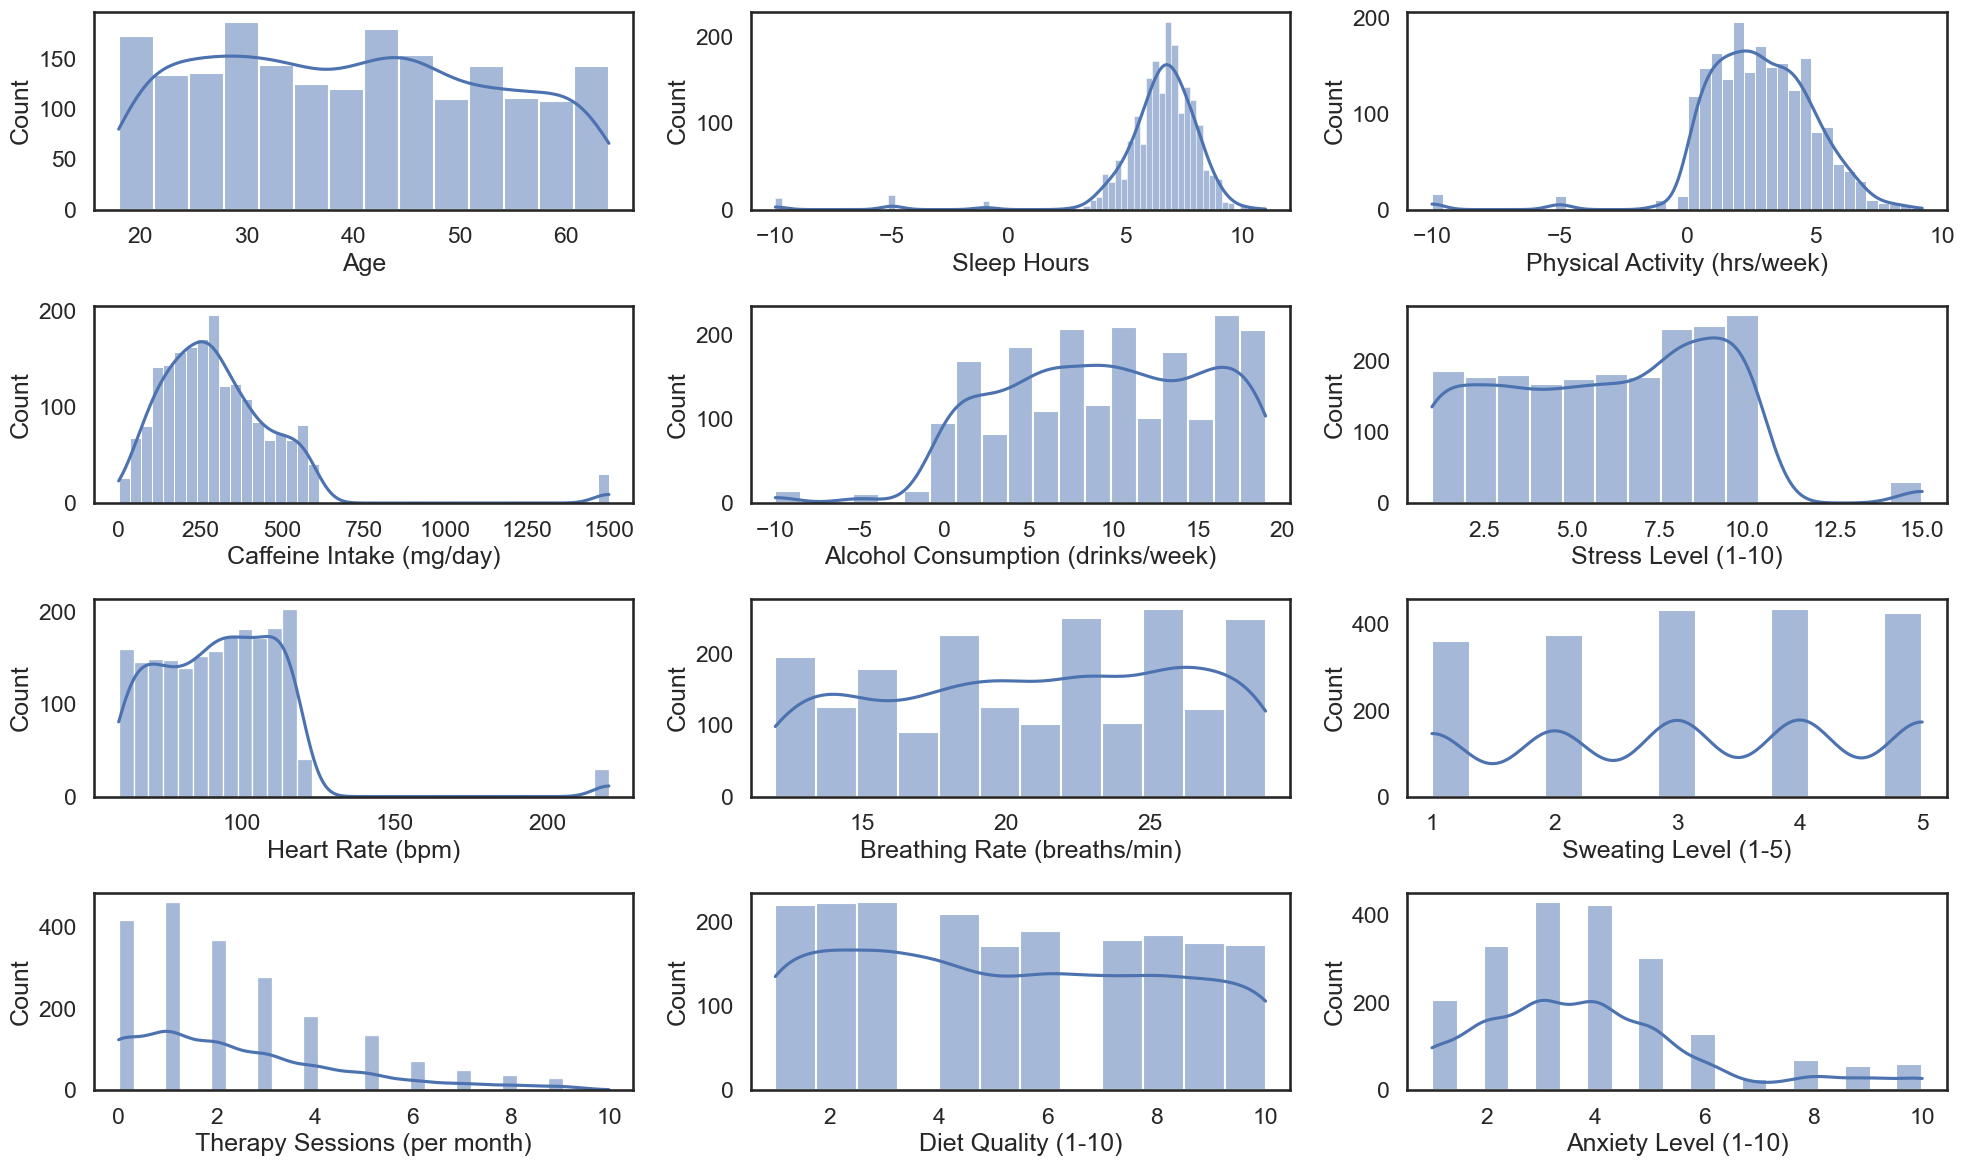

In [76]:
fig, ax = plt.subplots(4,3, figsize=(20,12))
ax = ax.flatten()
for i, v in enumerate(num_data):
    sns.histplot(data[v], ax=ax[i], kde=True)

plt.tight_layout()
plt.show()


In [135]:
def qqplot_shapiro(col:str):
    from scipy.stats import shapiro

    fig = plt.figure(figsize=(6, 6))

    stats.probplot(data[col].dropna(), dist="norm", plot=plt)

    stat, p = shapiro(data[col].dropna())

    plt.title(f"QQplot {col}  shapiro p: {p:.4f}")
    plt.show()

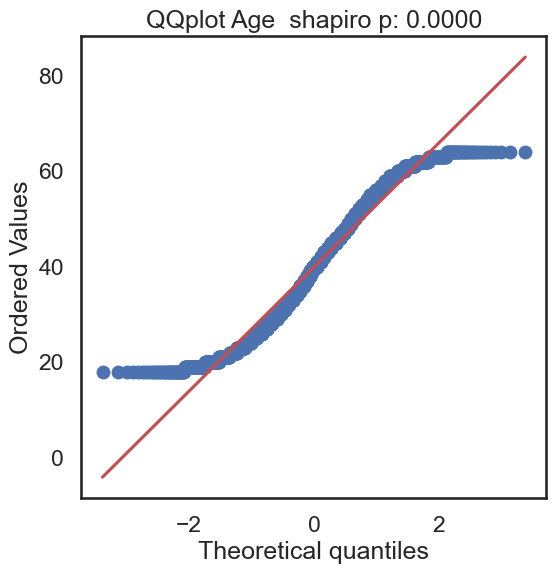

In [136]:
qqplot_shapiro("Age")

In [125]:
def anxiety_analysis(df:pd.DataFrame, x:str):
    fig, ax = plt.subplots(1,3, figsize=(20,8))

    sns.histplot(data=df, x=x, hue="is_Anxious", multiple = "stack", ax=ax[0])
    ax[0].set_title(f"stack of {x}")

    sns.histplot(data=df, x=x, hue="is_Anxious", multiple = "fill", ax=ax[1])
    ax[1].set_title(f"stack proportion of {x}")

    sns.kdeplot(data=df, x=x, hue="is_Anxious", fill=True, ax=ax[2])
    ax[2].set_title(f"kde of {x}")


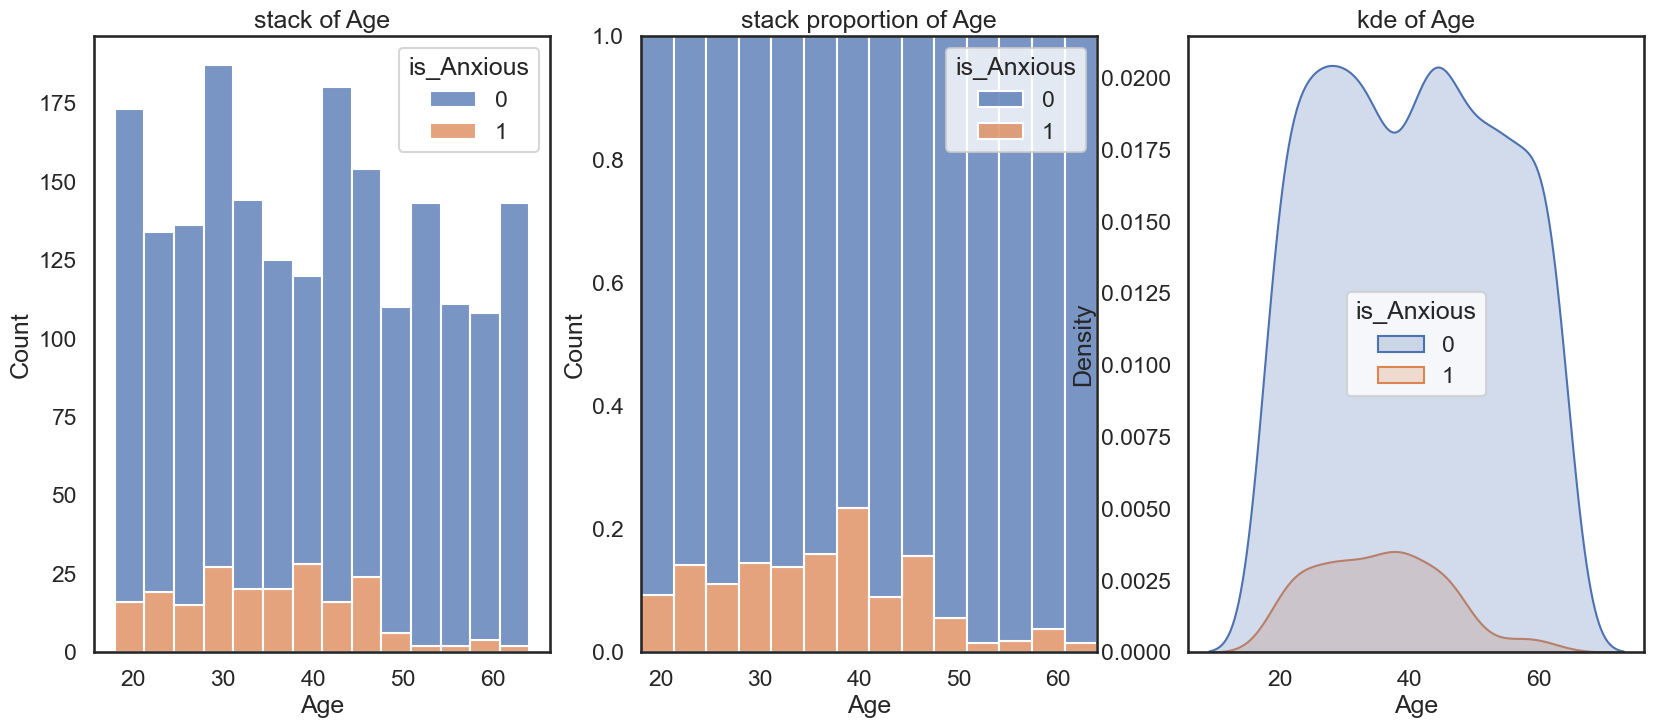

In [126]:
anxiety_analysis(data, "Age")

In [85]:
def corr_heatmap(numeric_cols, method="spearman"):
    cor = numeric_cols.corr(method=method)
    plt.figure(figsize=(15, 10))
    sns.heatmap(cor, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, center=0, annot_kws={"size": 10})
    plt.title(f"Correlation Heatmap: {method}")

    plt.tight_layout()
    plt.show()


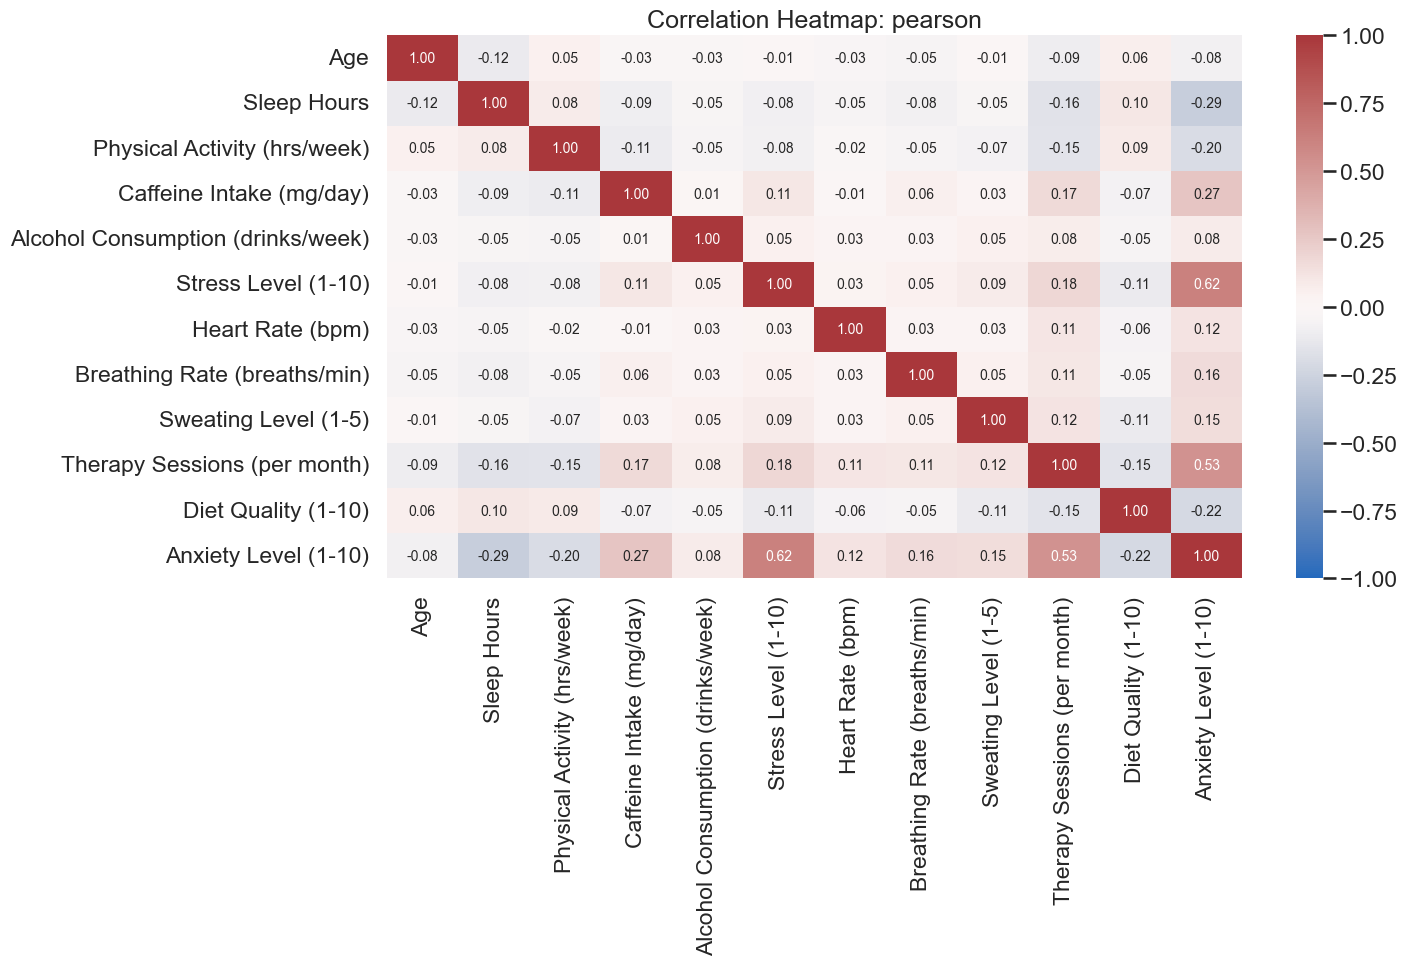

In [87]:
corr_heatmap(data[num_data], method="pearson")

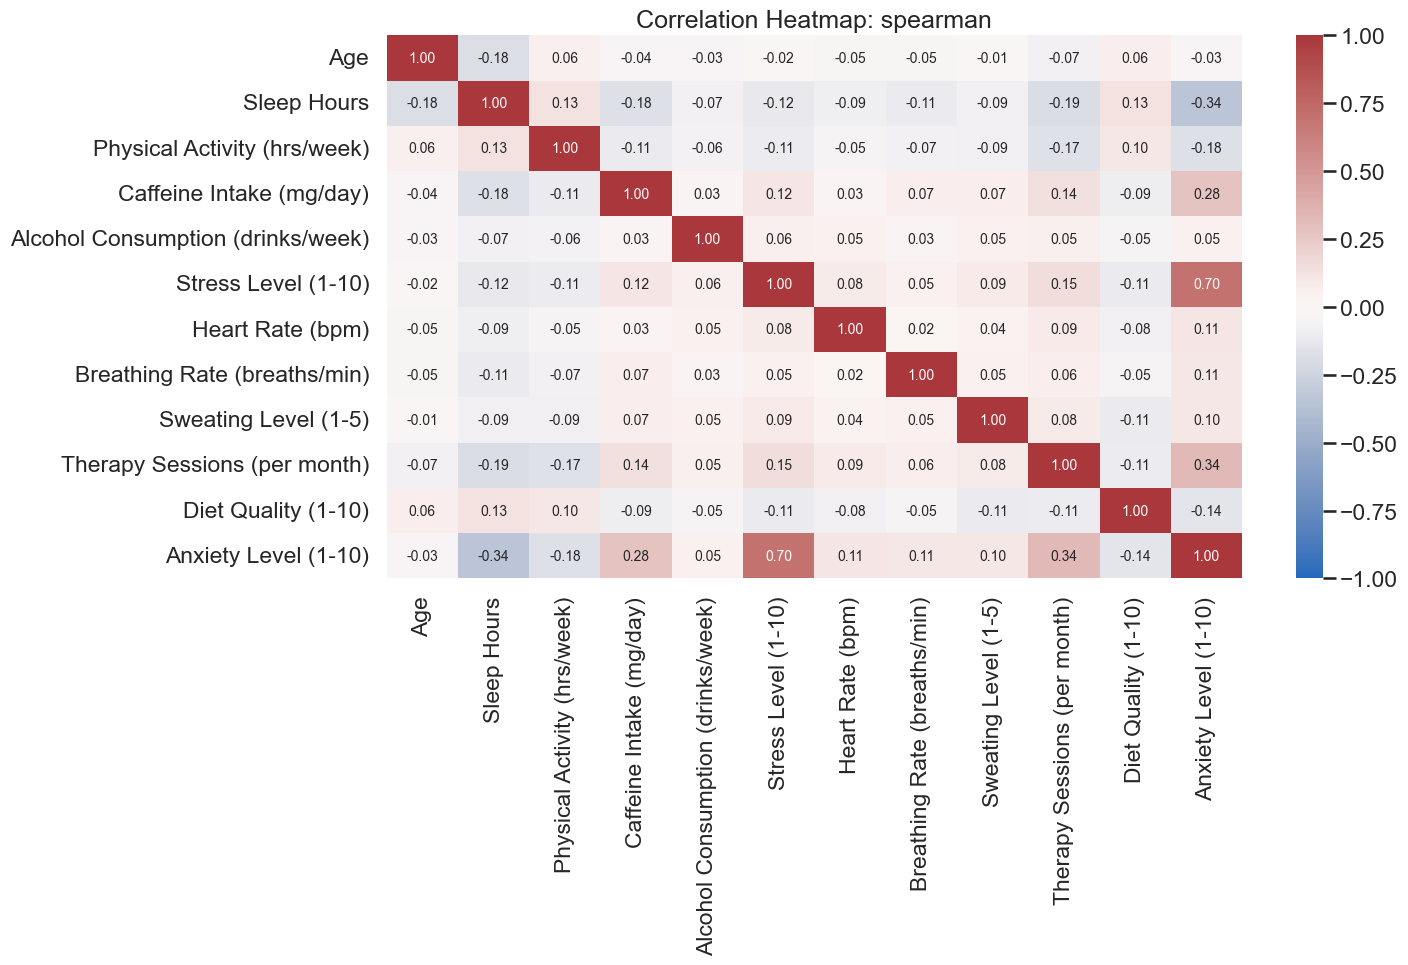

In [88]:
corr_heatmap(data[num_data])

In [94]:
def pvalue_heatmap(num_cols, method="spearmanr"):
    from scipy.stats import spearmanr, pearsonr

    if method == "spearmanr":
        corr, pval = spearmanr(num_cols.dropna())
    else:
        corr, pval = pearsonr(data["Age"])

    p_matrix = pd.DataFrame(pval, index=num_data, columns=num_data)
    plt.figure(figsize=(15, 10))

    sns.heatmap(p_matrix, annot=True, fmt=".2f", cmap="YlGn_r", vmin=0, vmax=0.05, annot_kws={"size": 8})
    plt.title(f"P_value Correlation Heatmap: {method}")

    plt.tight_layout()
    plt.show()


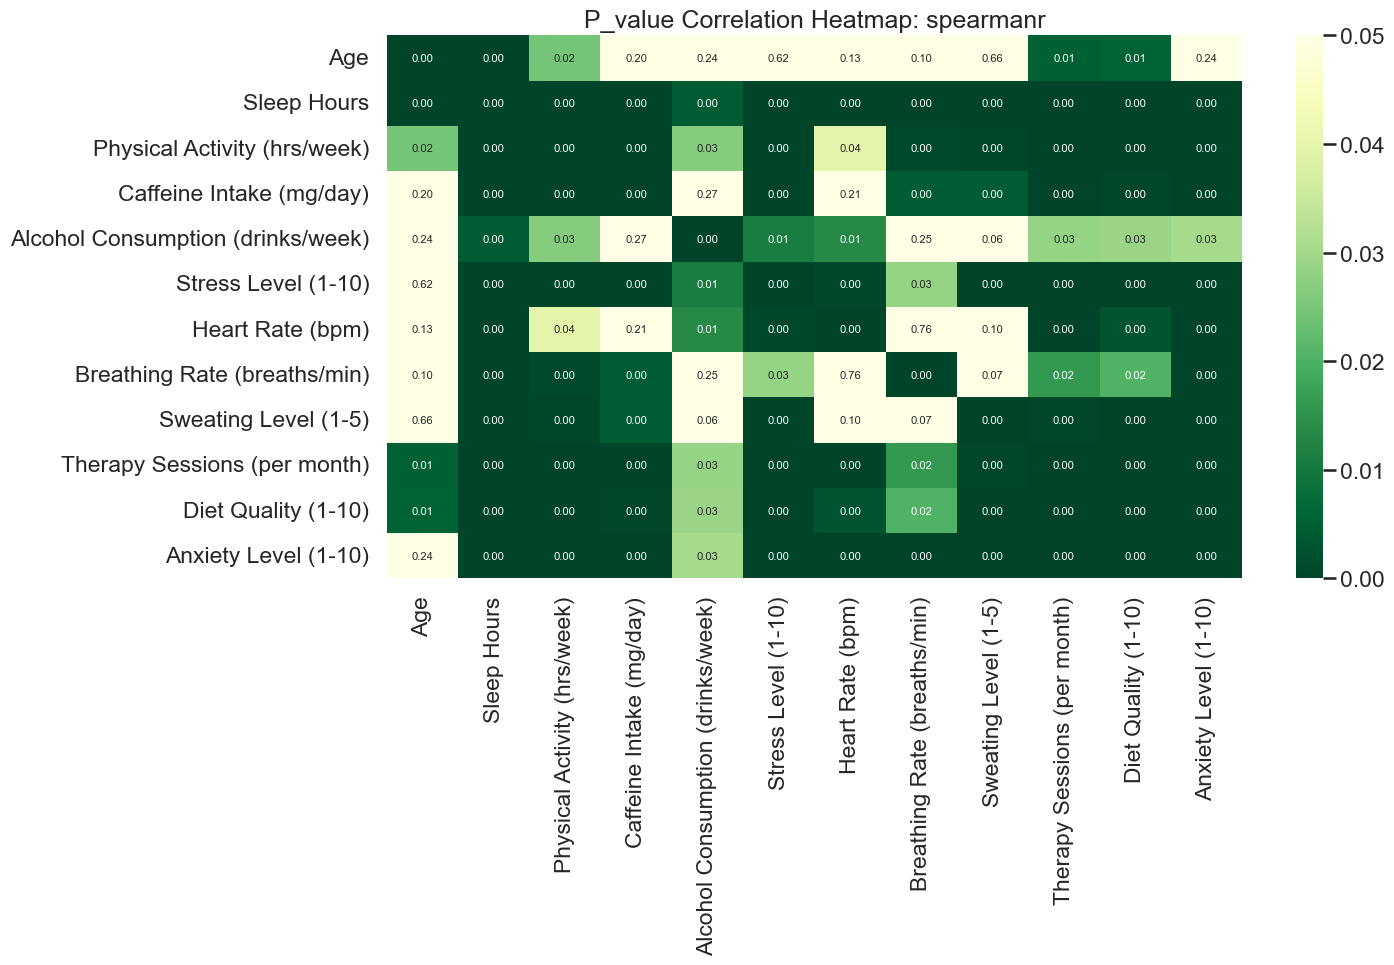

In [95]:
pvalue_heatmap(data[num_data])